[Previous: Module 3: Multiple Qubits & Entanglement](03_Multiple_Qubits_and_Entanglement.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 5: Quantum Teleportation](05_Quantum_Teleportation.ipynb)

# Module 4: Measurement & Interference

**Learning objectives.** After this module you can:

* apply the Born rule to any state and explain why shot counts scatter around it;
* measure in the X basis to reveal a phase that the Z basis cannot see;
* trace through an interference calculation amplitude by amplitude;
* build a one-qubit interferometer and show its output follows $\cos^2(\phi/2)$.

**Prerequisites.** [Module 2](02_Quantum_Logic_Gates.ipynb) (H, RZ) and [Module 3](03_Multiple_Qubits_and_Entanglement.ipynb).

## 1. The Born rule

For any state $|\psi\rangle = \sum_x a_x |x\rangle$, measuring gives outcome $x$ with probability

$$P(x) = |a_x|^2.$$

For $|+\rangle = \tfrac{1}{\sqrt2}|0\rangle + \tfrac{1}{\sqrt2}|1\rangle$ that is $\tfrac12$ and $\tfrac12$. For $\tfrac{1}{\sqrt2}|0\rangle - \tfrac{1}{\sqrt2}|1\rangle$
it is *also* $\tfrac12$ and $\tfrac12$: the minus sign vanishes when you square. Keep that in mind; section 3 comes back to it.

`Statevector.probabilities_dict()` applies the Born rule exactly. `Statevector.sample_counts(shots)` samples from it, like a device would.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator

simulator = AerSimulator()

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

examples = {
    "|+>":              Statevector([1, 1]) / np.sqrt(2),
    "|->":              Statevector([1, -1]) / np.sqrt(2),
    "0.6|0> + 0.8|1>":  Statevector([0.6, 0.8]),
    "Bell |Φ+>":        Statevector(bell),
}
for name, sv in examples.items():
    exact = {k: round(float(v), 3) for k, v in sv.probabilities_dict().items()}
    sampled = dict(sv.sample_counts(1000))
    print(f"{name:<18} exact {exact}   sampled(1000) {sampled}")

|+>                exact {np.str_('0'): 0.5, np.str_('1'): 0.5}   sampled(1000) {np.str_('0'): np.int64(508), np.str_('1'): np.int64(492)}
|->                exact {np.str_('0'): 0.5, np.str_('1'): 0.5}   sampled(1000) {np.str_('0'): np.int64(500), np.str_('1'): np.int64(500)}
0.6|0> + 0.8|1>    exact {np.str_('0'): 0.36, np.str_('1'): 0.64}   sampled(1000) {np.str_('0'): np.int64(372), np.str_('1'): np.int64(628)}
Bell |Φ+>          exact {np.str_('00'): 0.5, np.str_('11'): 0.5}   sampled(1000) {np.str_('00'): np.int64(493), np.str_('11'): np.int64(507)}


## 2. Shot noise: how many shots is enough?

Each shot is a coin flip with bias $p$. After $N$ shots the estimate $\hat p$ has standard error

$$\sigma = \sqrt{\frac{p(1-p)}{N}}.$$

Ten times more shots buys only $\sqrt{10} \approx 3.2$ times more precision. Below, five independent runs at each shot count
show the spread shrinking exactly as the formula predicts.

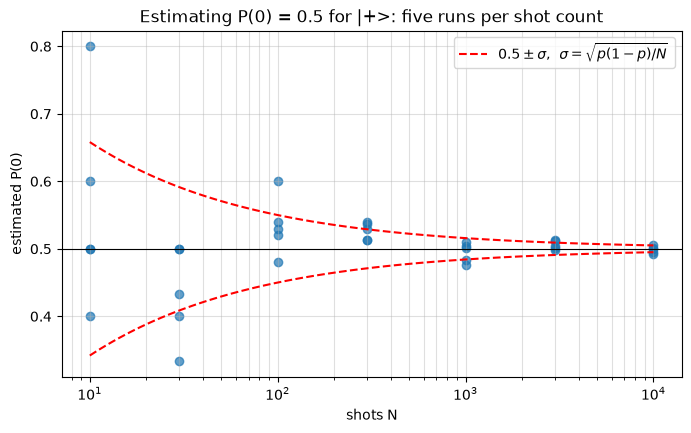

In [2]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

shot_counts = [10, 30, 100, 300, 1000, 3000, 10000]
trials = 5

plt.figure(figsize=(8, 4.5))
for N in shot_counts:
    estimates = [simulator.run(qc, shots=N).result().get_counts().get('0', 0) / N for _ in range(trials)]
    plt.scatter([N]*trials, estimates, color='tab:blue', alpha=0.7)

N_line = np.logspace(1, 4, 100)
sigma = np.sqrt(0.25 / N_line)
plt.plot(N_line, 0.5 + sigma, 'r--', label=r'$0.5 \pm \sigma$,  $\sigma=\sqrt{p(1-p)/N}$')
plt.plot(N_line, 0.5 - sigma, 'r--')
plt.axhline(0.5, color='k', lw=0.8)
plt.xscale('log'); plt.xlabel('shots N'); plt.ylabel('estimated P(0)')
plt.title('Estimating P(0) = 0.5 for |+>: five runs per shot count')
plt.legend(); plt.grid(True, which='both', alpha=0.4); plt.show()

> **What to notice.** With 10 shots the estimate can be 0.2 or 0.8. With 10 000 shots it is within about 0.01.
> When you compare a histogram to a theory value, always ask "how many shots?" first.

## 3. The invisible phase, and how to see it

$|+\rangle$ and $|-\rangle$ give identical Z-measurement statistics, yet they are different states (opposite sides of the Bloch sphere).
The difference is the **relative phase**, and the Z basis is blind to it.

The fix is to **change the measurement basis**. Measuring "along X" means: rotate the X axis onto the Z axis (apply H), then measure normally.
Since $H|+\rangle = |0\rangle$ and $H|-\rangle = |1\rangle$, the two states now give opposite, deterministic answers.

The general rule: measurement in basis $B$ = apply the gate that maps $B$ onto the Z axis, then measure.

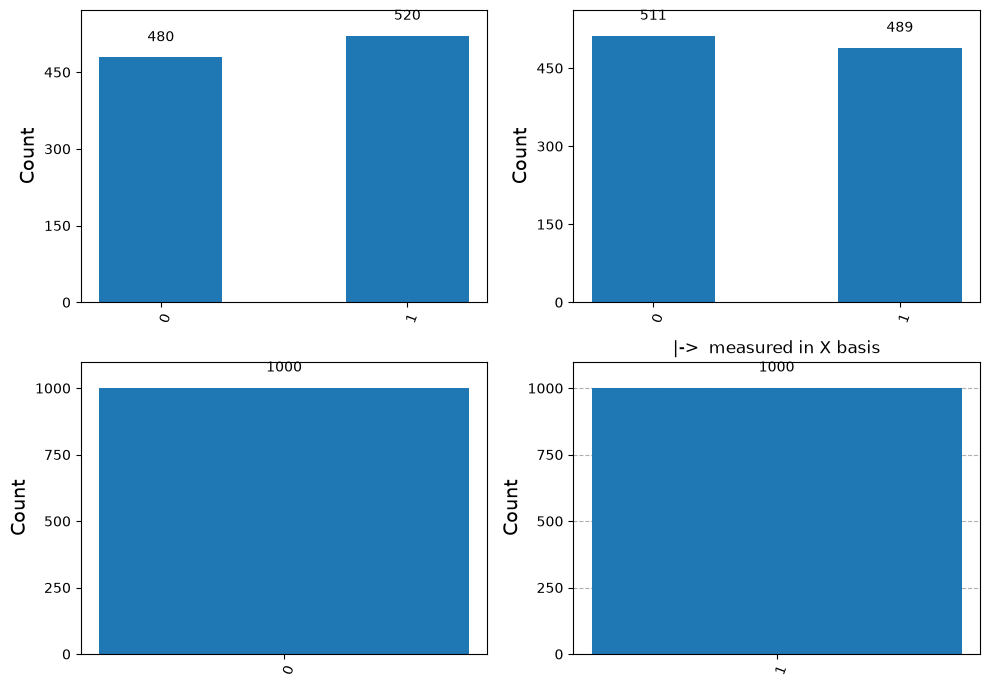

In [3]:
def prepare(sign):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    if sign == '-':
        qc.z(0)          # |+> -> |->
    return qc

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, basis in enumerate(['Z', 'X']):
    for col, sign in enumerate(['+', '-']):
        qc = prepare(sign)
        if basis == 'X':
            qc.h(0)      # rotate X axis onto Z axis
        qc.measure(0, 0)
        counts = simulator.run(qc, shots=1000).result().get_counts()
        plot_histogram(counts, ax=axes[row][col], title=f"|{sign}>  measured in {basis} basis")
plt.tight_layout(); plt.show()

> **What to notice.** Top row: $|+\rangle$ and $|-\rangle$ look identical. Bottom row: after an H they are perfectly distinguishable.
> No information was lost; it was stored in the phase, and the right measurement reads it out.

## 4. Interference: amplitudes add, then you square

Apply H to $|0\rangle$ and you get a 50/50 superposition. Apply H *again* and, instead of "random twice = random", you get $|0\rangle$ with certainty.
Follow the amplitudes:

$$H|0\rangle = \tfrac{1}{\sqrt2}|0\rangle + \tfrac{1}{\sqrt2}|1\rangle$$

Apply H to each term:

$$\tfrac{1}{\sqrt2}\underbrace{\Big(\tfrac{1}{\sqrt2}|0\rangle + \tfrac{1}{\sqrt2}|1\rangle\Big)}_{H|0\rangle}
+ \tfrac{1}{\sqrt2}\underbrace{\Big(\tfrac{1}{\sqrt2}|0\rangle - \tfrac{1}{\sqrt2}|1\rangle\Big)}_{H|1\rangle}
= \Big(\tfrac12 + \tfrac12\Big)|0\rangle + \Big(\tfrac12 - \tfrac12\Big)|1\rangle = |0\rangle.$$

Two paths lead to $|1\rangle$ with amplitudes $+\tfrac12$ and $-\tfrac12$. They **cancel** (destructive interference).
Two paths lead to $|0\rangle$ with amplitudes $+\tfrac12$ and $+\tfrac12$. They **reinforce** (constructive interference).
A classical spinning coin has no negative probabilities and can never do this.

The bar charts below show the amplitudes (not probabilities) after each gate. Watch the sign.

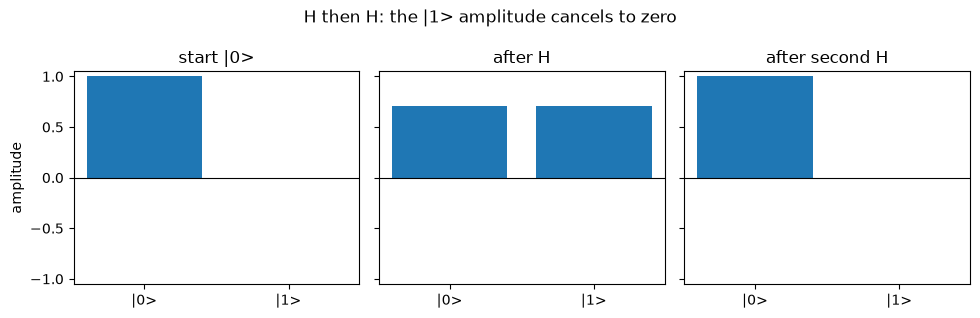

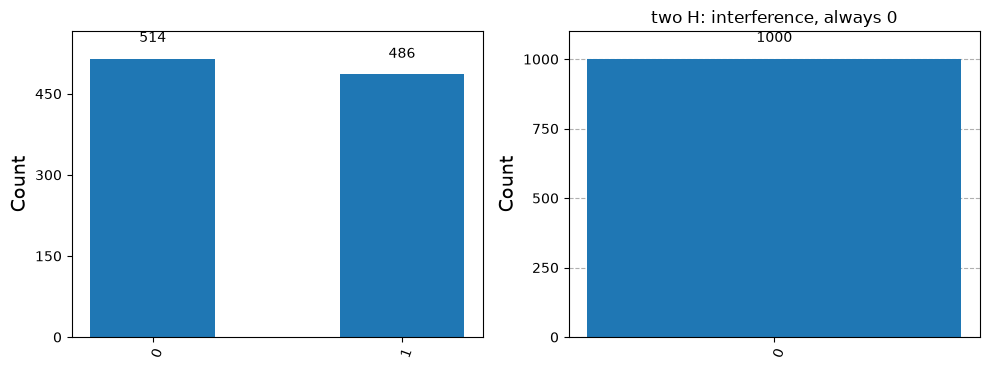

In [4]:
def amplitude_bars(states, titles, suptitle):
    fig, axes = plt.subplots(1, len(states), figsize=(3.3*len(states), 3.2), sharey=True)
    for ax, sv, t in zip(axes, states, titles):
        amps = sv.data.real
        labels = [f"|{format(i, f'0{sv.num_qubits}b')}>" for i in range(len(amps))]
        ax.bar(labels, amps, color=['tab:blue' if a >= 0 else 'tab:red' for a in amps])
        ax.axhline(0, color='k', lw=0.8); ax.set_ylim(-1.05, 1.05); ax.set_title(t)
    axes[0].set_ylabel('amplitude'); fig.suptitle(suptitle); plt.tight_layout(); plt.show()

h = QuantumCircuit(1)
h.h(0)
s0 = Statevector.from_label('0')
s1 = s0.evolve(h)          # after one H
s2 = s1.evolve(h)          # after the second H
amplitude_bars([s0, s1, s2], ["start |0>", "after H", "after second H"], "H then H: the |1> amplitude cancels to zero")

# The same experiment on the simulator
qc1 = QuantumCircuit(1, 1); qc1.h(0); qc1.measure(0, 0)
qc2 = QuantumCircuit(1, 1); qc2.h(0); qc2.h(0); qc2.measure(0, 0)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
plot_histogram(simulator.run(qc1, shots=1000).result().get_counts(), ax=ax[0], title="one H: random")
plot_histogram(simulator.run(qc2, shots=1000).result().get_counts(), ax=ax[1], title="two H: interference, always 0")
plt.tight_layout(); plt.show()

## 5. A quantum interferometer: H, RZ($\phi$), H

The double-Hadamard is an interferometer with the phase set to zero. Insert a phase rotation between the two H gates and you can dial the interference
from fully constructive to fully destructive:

$$|0\rangle \xrightarrow{H} \tfrac{1}{\sqrt2}(|0\rangle + |1\rangle)
\xrightarrow{R_z(\phi)} \tfrac{1}{\sqrt2}(e^{-i\phi/2}|0\rangle + e^{i\phi/2}|1\rangle)
\xrightarrow{H} \cos\tfrac{\phi}{2}\,|0\rangle - i\sin\tfrac{\phi}{2}\,|1\rangle$$

$$\boxed{P(0) = \cos^2\frac{\phi}{2}}$$

This is the quantum version of the Mach-Zehnder interferometer in optics: split, shift one arm, recombine. Every quantum algorithm is, at heart,
an interferometer arranged so that wrong answers cancel and right answers reinforce.

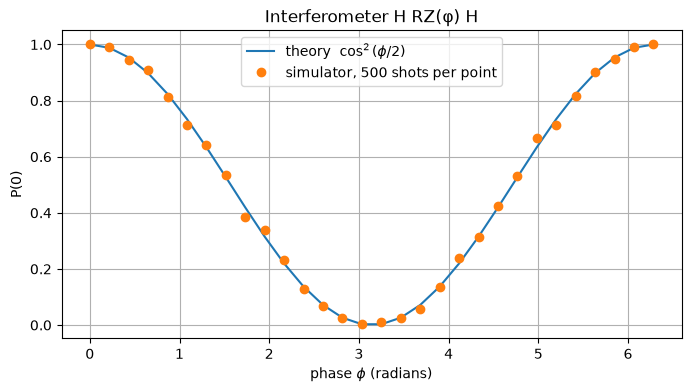

In [5]:
phis = np.linspace(0, 2*np.pi, 30)
measured = []
for phi in phis:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.rz(phi, 0)
    qc.h(0)
    qc.measure(0, 0)
    counts = simulator.run(qc, shots=500).result().get_counts()
    measured.append(counts.get('0', 0) / 500)

plt.figure(figsize=(8, 4))
plt.plot(phis, np.cos(phis/2)**2, label=r'theory  $\cos^2(\phi/2)$')
plt.plot(phis, measured, 'o', label='simulator, 500 shots per point')
plt.xlabel(r'phase $\phi$ (radians)'); plt.ylabel('P(0)')
plt.title('Interferometer H RZ(φ) H'); plt.legend(); plt.grid(True); plt.show()

interactive(children=(FloatSlider(value=0.0, description='φ', max=6.283185307179586), Output()), _dom_classes=…

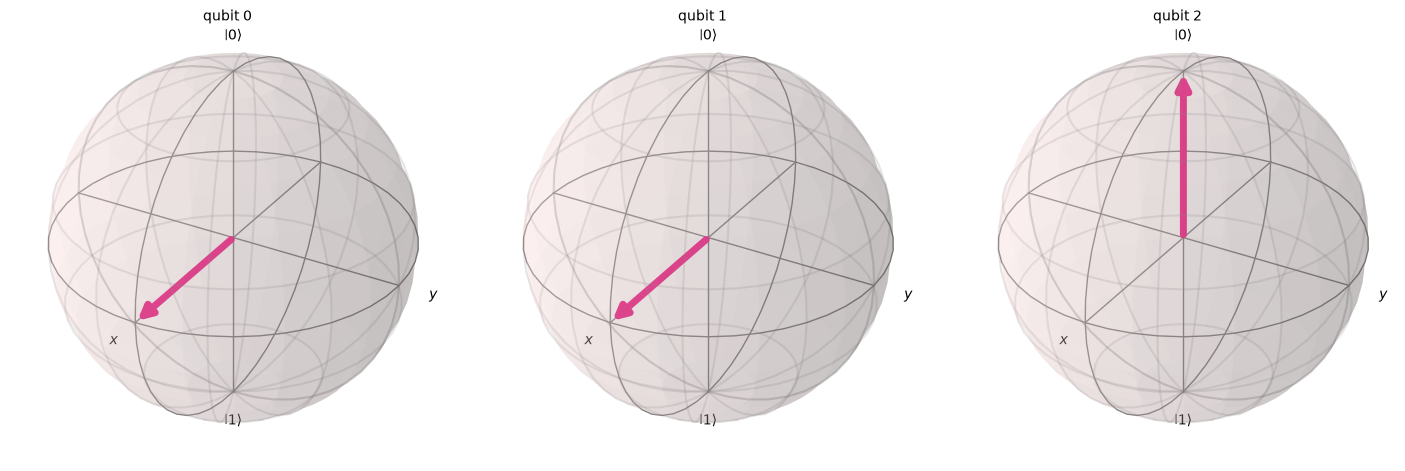

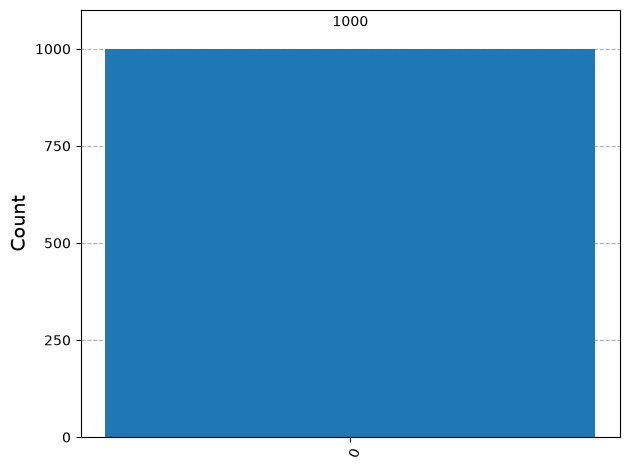

In [6]:
%matplotlib inline
from ipywidgets import interact, FloatSlider

def interferometer(phi):
    # Three qubits show the three stages side by side: after H, after RZ, after the final H.
    stages = QuantumCircuit(3)
    stages.h([0, 1, 2])
    stages.rz(phi, [1, 2])
    stages.h(2)
    print("qubit 0: after H     qubit 1: after RZ(φ)     qubit 2: after final H")
    display(plot_bloch_multivector(Statevector(stages)))

    qc = QuantumCircuit(1, 1); qc.h(0); qc.rz(phi, 0); qc.h(0); qc.measure(0, 0)
    counts = simulator.run(qc, shots=1000).result().get_counts()
    print(f"φ = {phi:.2f}   theory P(0) = {np.cos(phi/2)**2:.3f}   measured = {counts.get('0', 0)/1000:.3f}")
    display(plot_histogram(counts))

interact(interferometer, phi=FloatSlider(min=0, max=2*np.pi, step=0.1, value=0, description='φ'));

> **What to notice.** RZ swings the middle sphere around the equator without changing its probabilities (qubit 1 stays 50/50).
> Only the final H converts that phase into a probability you can measure. Phase is invisible until interference makes it visible.

## 6. Aside: the classical wave picture

If interference still feels abstract, here is the everyday version. Two waves with a relative phase add up: in phase they double, out of phase they cancel.
Quantum amplitudes behave like wave heights; probabilities behave like wave *intensity* (height squared). This is only an analogy, but it is the right one.

In [7]:
def plot_waves(phase_shift):
    x = np.linspace(0, 4*np.pi, 500)
    y1, y2 = np.sin(x), np.sin(x + phase_shift)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
    ax1.plot(x, y1, color='tab:blue');   ax1.set_title('Wave 1');                                        ax1.grid(True)
    ax2.plot(x, y2, color='tab:orange'); ax2.set_title(f'Wave 2, shifted by {phase_shift:.2f} rad');     ax2.grid(True)
    ax3.plot(x, y1 + y2, color='tab:green', lw=2); ax3.set_title('Sum (interference)'); ax3.set_ylim(-2.5, 2.5); ax3.grid(True)
    plt.tight_layout(); plt.show()

interact(plot_waves, phase_shift=FloatSlider(min=0, max=2*np.pi, step=0.1, value=0, description='phase'));

interactive(children=(FloatSlider(value=0.0, description='phase', max=6.283185307179586), Output()), _dom_clas…

## Try it yourself

**Exercise 1.** Predict the measurement result of H, Z, H on $|0\rangle$ using the amplitude arithmetic of section 4. Then check.

**Exercise 2.** Which phase $\phi$ in the interferometer gives $P(0) = 0.25$? Set it and run 2000 shots.

**Exercise 3.** Measure the Bell state $|\Phi^+\rangle$ in the X basis on *both* qubits. Are the qubits still perfectly correlated?

**Exercise 4 (challenge).** Build a Y-basis measurement. Which gate maps the Y axis onto the Z axis? (Hint: $S^\dagger$ then H.) Test on $|i\rangle$ = `Statevector.from_label('r')`.

<details><summary>Solutions</summary>

```python
# Exercise 1: Z flips the sign of the |1> amplitude, so the second H now cancels |0> instead: result is always 1.
qc = QuantumCircuit(1, 1); qc.h(0); qc.z(0); qc.h(0); qc.measure(0, 0)
print(simulator.run(qc, shots=1000).result().get_counts())         # {'1': 1000}

# Exercise 2: cos²(φ/2) = 0.25 -> φ/2 = 60° -> φ = 2π/3
phi = 2*np.pi/3
qc = QuantumCircuit(1, 1); qc.h(0); qc.rz(phi, 0); qc.h(0); qc.measure(0, 0)
print(simulator.run(qc, shots=2000).result().get_counts())

# Exercise 3: yes. (H⊗H)|Φ+> = |Φ+>, so X-basis outcomes also always agree.
qc = QuantumCircuit(2, 2); qc.h(0); qc.cx(0, 1); qc.h([0, 1]); qc.measure([0, 1], [0, 1])
print(simulator.run(qc, shots=1000).result().get_counts())         # only '00' and '11'

# Exercise 4: S† then H maps |i> to |0>
qc = QuantumCircuit(1, 1); qc.initialize(Statevector.from_label('r'), 0); qc.sdg(0); qc.h(0); qc.measure(0, 0)
print(simulator.run(qc, shots=1000).result().get_counts())         # {'0': 1000}
```

</details>

## Key takeaways

* Born rule: $P(x) = |a_x|^2$. Counts scatter around it with standard error $\sqrt{p(1-p)/N}$.
* Z measurement cannot see relative phase. Rotate the basis (H for X, $S^\dagger H$ for Y) and it can.
* Interference: amplitudes for the same outcome add *before* squaring, so paths can cancel.
* The interferometer H RZ(φ) H gives $P(0) = \cos^2(\phi/2)$: phase in, probability out. Every algorithm is built on this.

**Next:** use entanglement and measurement together to move a quantum state across a room. [Module 5](05_Quantum_Teleportation.ipynb).

[Previous: Module 3: Multiple Qubits & Entanglement](03_Multiple_Qubits_and_Entanglement.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 5: Quantum Teleportation](05_Quantum_Teleportation.ipynb)